In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model

2026-06-26 16:51:55.592526: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-26 16:51:55.673108: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-26 16:51:55.673155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-26 16:51:55.675610: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-26 16:51:55.694180: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-26 16:51:55.695136: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
## Find all Weather.csv files

DATA_ROOT = Path("../data/csv")

weather_files = sorted(DATA_ROOT.glob("*/Weather.csv"))

print(f"Found {len(weather_files)} files\n")

for i, f in enumerate(weather_files):
    print(i, f.parent.name)

Found 3 files

0 Huis_19_06_2026_30min
1 Huis_19_06_2026_all
2 Huis_may_2025


In [3]:
## Loader

def load_weather_file(path):
    df = pd.read_csv(
        path,
        skiprows=5,
        sep=",",
        engine="python"
    )

    df.columns = [str(c).strip() for c in df.columns]

    df = df.rename(columns={
        "Timezone : Europe/Amsterdam": "datetime"
    })

    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])

    return df

In [4]:
## Load data

path = weather_files[2]
df = load_weather_file(path)

print(path.parent.name)
df.head()

Huis_may_2025


,Timestamp,datetime,Temperature °C,Humidity %,CO2 ppm,Noise dB,Pressure Pa,Unnamed: 7,Temperature °C.1,Humidity %.1,Unnamed: 10
0,1745964150,2025-04-30 00:02:30,22.3,52,1168,32,1022.7,NaN,14.1,80.0,NaN
1,1745964450,2025-04-30 00:07:30,22.3,52,1168,32,1022.7,NaN,14.2,80.0,NaN
2,1745964750,2025-04-30 00:12:30,22.2,52,1168,32,1022.7,NaN,14.1,80.0,NaN
3,1745965050,2025-04-30 00:17:30,22.3,52,1141,33,1022.7,NaN,14.1,80.0,NaN
4,1745965350,2025-04-30 00:22:30,22.2,52,1141,34,1022.7,NaN,14.1,81.0,NaN


In [5]:
df = df.rename(columns={
    "Temperature °C": "temp_in",
    "Temperature °C.1": "temp_out",
    "Humidity %.1": "hum_out"
})

df = df[["datetime", "temp_in", "temp_out", "hum_out"]].dropna()

df["hour"] = df["datetime"].dt.hour
df["dayofyear"] = df["datetime"].dt.dayofyear

df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
df["day_sin"] = np.sin(2*np.pi*df["dayofyear"]/365.25)
df["day_cos"] = np.cos(2*np.pi*df["dayofyear"]/365.25)

In [6]:
feature_columns = [
    "temp_out",
    "hum_out",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
]

target_column = "temp_in"

df = df.dropna().reset_index(drop=True)

X = df[feature_columns]
y = df[target_column]

In [7]:
n = len(df)

train_end = int(0.7*n)
val_end = int(0.85*n)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

In [8]:
# scaler_x = StandardScaler()
# scaler_y = StandardScaler()

# X_train = scaler_x.fit_transform(train_df[feature_columns])
# X_val = scaler_x.transform(val_df[feature_columns])
# X_test = scaler_x.transform(test_df[feature_columns])

# y_train = scaler_y.fit_transform(train_df[[target_column]])
# y_val = scaler_y.transform(val_df[[target_column]])
# y_test = scaler_y.transform(test_df[[target_column]])

In [9]:
from scipy.optimize import minimize

DT = 300.0  # seconds (5-minute sampling)


def simulate_2r2c(theta, T_out, T_air0):
    """
    Simulate the 2R2C thermal model.

    Parameters
    ----------
    theta : array-like
        [R_ow, R_iw, C_w, C_a, T_wall0]

    T_out : ndarray
        Outdoor temperature time series.

    T_air0 : float
        Initial indoor temperature.

    Returns
    -------
    T_air : ndarray
        Predicted indoor temperature.
    """

    R_ow, R_iw, C_w, C_a, T_wall0 = theta

    n = len(T_out)

    T_air = np.zeros(n)
    T_wall = np.zeros(n)

    T_air[0] = T_air0
    T_wall[0] = T_wall0

    for k in range(n - 1):

        q_out = (T_out[k] - T_wall[k]) / R_ow
        q_wall = (T_wall[k] - T_air[k]) / R_iw

        dT_wall = (q_out - q_wall) / C_w
        dT_air = q_wall / C_a

        T_wall[k + 1] = T_wall[k] + DT * dT_wall
        T_air[k + 1] = T_air[k] + DT * dT_air

    return T_air

In [10]:
def objective(theta, T_out, T_measured):
    """
    Least-squares objective used for parameter estimation.
    """

    prediction = simulate_2r2c(
        theta,
        T_out,
        T_measured[0]
    )

    return np.mean((prediction - T_measured) ** 2)

In [18]:
T_out_train = train_df["temp_out"].values
T_air_train = train_df["temp_in"].values

In [12]:
initial_guess = [
    2.0,      # R_ow
    0.5,      # R_iw
    5e5,      # C_w
    5e4,      # C_a
    T_air_train[0]
]

In [13]:
result = minimize(
    objective,
    initial_guess,
    args=(T_out_train, T_air_train),
    method="L-BFGS-B",
    bounds=bounds
)

theta_hat = result.x

print("Optimization successful:", result.success)
print(result.message)

Optimization successful: True
CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


In [14]:
parameter_names = [
    "R_ow",
    "R_iw",
    "C_w",
    "C_a",
    "T_wall0"
]

print()

for name, value in zip(parameter_names, theta_hat):
    print(f"{name:10s}: {value:.4f}")


R_ow      : 20.0000
R_iw      : 0.0100
C_w       : 500000.0002
C_a       : 50000.0002
T_wall0   : 22.2113


In [19]:
T_out_val = val_df["temp_out"].values
T_air_val = val_df["temp_in"].values

In [20]:
T_air_pred_val = simulate_2r2c(
    theta_hat,
    T_out_val,
    T_air_val[0]
)

In [23]:
mae = mean_absolute_error(
    T_air_val,
    T_air_pred_val
)

rmse = np.sqrt(
    mean_squared_error(
        T_air_val,
        T_air_pred_val
    )
)

print(f"Validation MAE : {mae:.3f} °C")
print(f"Validation RMSE: {rmse:.3f} °C")

Validation MAE : 1.825 °C
Validation RMSE: 2.189 °C


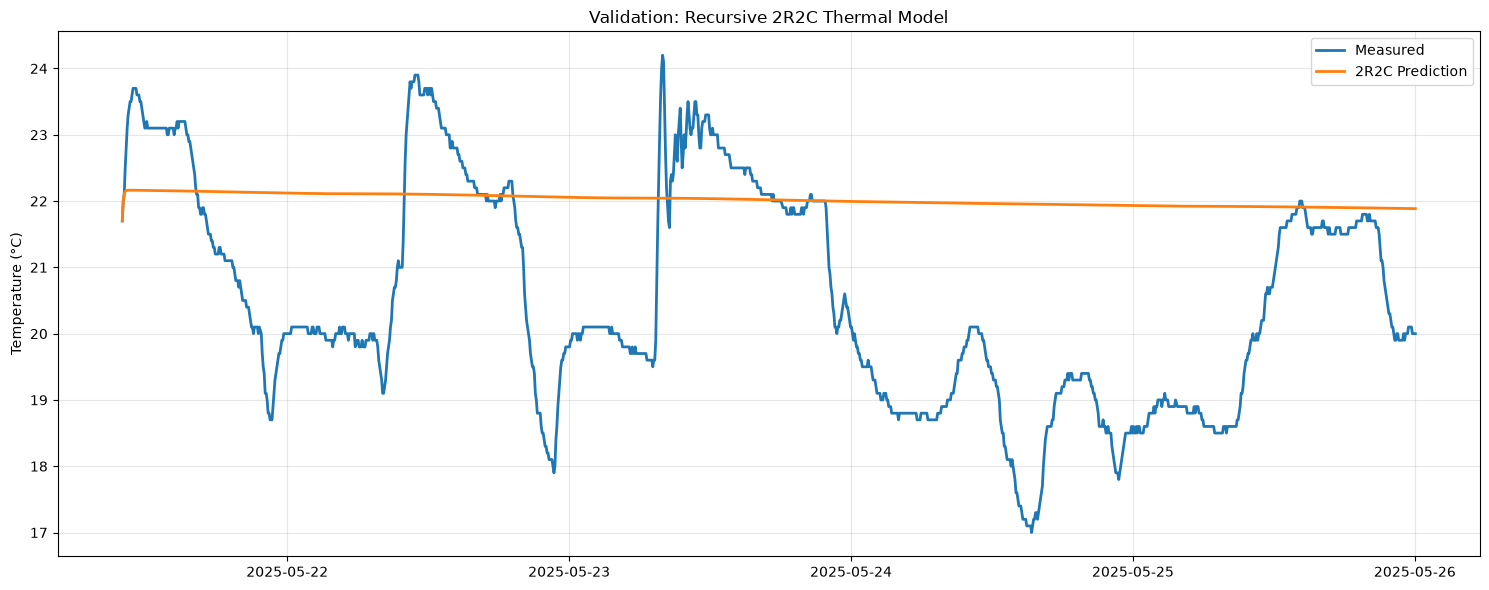

In [24]:
val_time = df.iloc[train_end:val_end]["datetime"]

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    val_time,
    T_air_val,
    label="Measured",
    linewidth=2
)

ax.plot(
    val_time,
    T_air_pred_val,
    label="2R2C Prediction",
    linewidth=2
)

ax.set_title("Validation: Recursive 2R2C Thermal Model")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
def create_sequences(X, y, lookback=48, horizon=12):
    Xs, ys = [], []

    for i in range(len(X) - lookback - horizon):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback:i+lookback+horizon].flatten())

    return np.array(Xs), np.array(ys)

LOOKBACK = 48      # past 4 hours (5-min data)
HORIZON = 12       # next 1 hour

X_train_seq, y_train_seq = create_sequences(X_train, y_train, LOOKBACK, HORIZON)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, LOOKBACK, HORIZON)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, LOOKBACK, HORIZON)

In [ ]:
inputs = layers.Input(shape=(LOOKBACK, len(feature_columns)))

x = layers.LSTM(64, return_sequences=True)(inputs)
x = layers.LSTM(32)(x)

x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(HORIZON)(x)

lstm_model = Model(inputs, outputs)

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

In [ ]:
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=256,
    verbose=1
)

In [ ]:
pred = lstm_model.predict(X_test_seq)

y_true = scaler_y.inverse_transform(y_test_seq)
y_pred = scaler_y.inverse_transform(pred)

mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

In [ ]:
def physics_model(temp_in, temp_out, alpha=0.02):
    return temp_in + alpha * (temp_out - temp_in)

In [ ]:
phys_preds = []

temp_in = test_df["temp_in"].iloc[0]

for t in range(len(test_df)):
    temp_out = test_df["temp_out"].iloc[t]
    temp_in = physics_model(temp_in, temp_out)
    phys_preds.append(temp_in)

phys_preds = np.array(phys_preds)

In [ ]:
physics_train = []

temp_in = train_df["temp_in"].iloc[0]

for t in range(len(train_df)):
    temp_out = train_df["temp_out"].iloc[t]
    temp_in = physics_model(temp_in, temp_out)
    physics_train.append(temp_in)

physics_train = np.array(physics_train)

residual_train = train_df["temp_in"].values - physics_train

In [ ]:
res_model = tf.keras.Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

res_model.compile(optimizer="adam", loss="mse")

In [ ]:
res_model.fit(
    scaler_x.transform(train_df[feature_columns]),
    residual_train,
    epochs=20,
    batch_size=256,
    verbose=1
)

In [ ]:
hybrid_preds = []

temp_in = test_df["temp_in"].iloc[0]

X_test_scaled = scaler_x.transform(test_df[feature_columns])

for i in range(len(test_df)):

    phys = physics_model(
        temp_in,
        test_df["temp_out"].iloc[i]
    )

    residual = res_model.predict(X_test_scaled[i:i+1], verbose=0)[0,0]

    temp_in = phys + residual
    hybrid_preds.append(temp_in)

hybrid_preds = np.array(hybrid_preds)

In [ ]:
true = test_df["temp_in"].values

def metrics(y_true, y_pred):
    return (
        mean_absolute_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred))
    )

print("Physics:", metrics(true, phys_preds))
print("Hybrid:", metrics(true, hybrid_preds))

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(true[:500], label="True")
plt.plot(phys_preds[:500], label="Physics")
plt.plot(hybrid_preds[:500], label="Hybrid")

plt.legend()
plt.title("Physics vs Hybrid Model")
plt.ylim([15, 30])
plt.show()